In [1]:
pip install pandas pyarrow


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   ----- ---------------------------------- 3.7/25.7 MB 24.3 MB/s eta 0:00:01
   --------------- ------------------------ 9.7/25.7 MB 24.2 MB/s eta 0:00:01
   ----------------------------- ---------- 18.6/25.7 MB 30.9 MB/s eta 0:00:01
   ---------------------------------------  25.4/25.7 MB 32.9 MB/s eta 0:00:01
   ---------------------------------------- 25.7/25.7 MB 27.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Replace with the path to one of your files
file_path = r"C:\Users\hp\Downloads\0000.parquet"

df = pd.read_parquet(file_path)

# Show the shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 900, Columns: 2


In [3]:
print(df.columns)
print(df.dtypes)


Index(['image', 'label'], dtype='object')
image    object
label     int64
dtype: object


In [4]:
# Look at first few rows
print(df.head(3))

# Or random samples
print(df.sample(3))


                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
                                                 image  label
325  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
171  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
341  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0


In [5]:
df2 = pd.read_parquet(r"C:\Users\hp\Downloads\0001.parquet")
print(df2.columns)


Index(['image', 'label'], dtype='object')


In [6]:
df3 = pd.read_parquet(r"C:\Users\hp\Downloads\0002.parquet")
print(df3.columns)


Index(['image', 'label'], dtype='object')


In [3]:
df4 = pd.read_parquet(r"C:\Users\hp\Downloads\0003.parquet")
print(df4.columns)
df5 = pd.read_parquet(r"C:\Users\hp\Downloads\0004.parquet")
print(df5.columns)
df6 = pd.read_parquet(r"C:\Users\hp\Downloads\0005.parquet")
print(df6.columns)
df7 = pd.read_parquet(r"C:\Users\hp\Downloads\0006.parquet")
print(df7.columns)
df8 = pd.read_parquet(r"C:\Users\hp\Downloads\0007.parquet")
print(df8.columns)
df9 = pd.read_parquet(r"C:\Users\hp\Downloads\0008.parquet")
print(df9.columns)
df10 = pd.read_parquet(r"C:\Users\hp\Downloads\0009.parquet")
print(df10.columns)





Index(['image', 'label'], dtype='object')
Index(['image', 'label'], dtype='object')
Index(['image', 'label'], dtype='object')
Index(['image', 'label'], dtype='object')
Index(['image', 'label'], dtype='object')
Index(['image', 'label'], dtype='object')
Index(['image', 'label'], dtype='object')


In [14]:
from PIL import Image, UnidentifiedImageError
from io import BytesIO

def decode_image(image_field):
    try:
        img_bytes = image_field['bytes']  # already bytes!
        image = Image.open(BytesIO(img_bytes)).convert("RGB")
        return image
    except (UnidentifiedImageError, KeyError, TypeError) as e:
        print("Error decoding image:", e)
        return None


In [16]:
img = decode_image(df_all['image'].iloc[0])
if img:
    img.show()


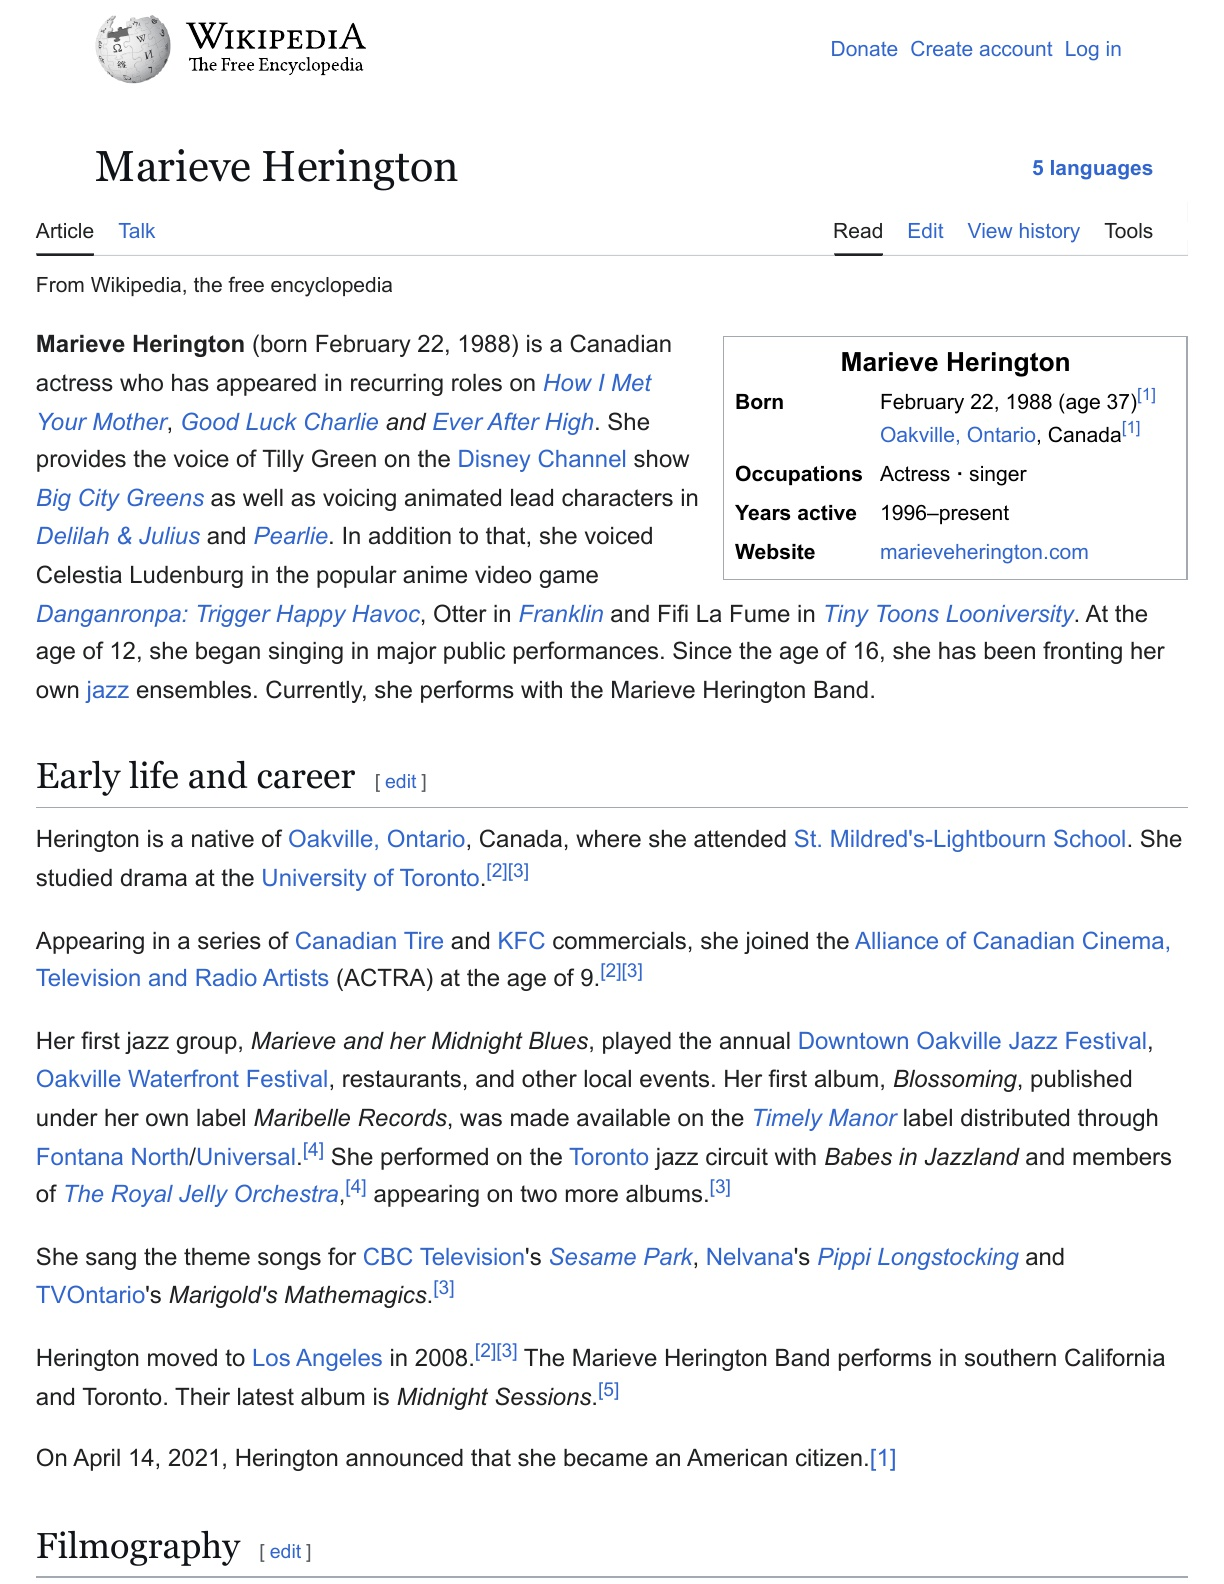

In [17]:
from IPython.display import display

img = decode_image(df_all['image'].iloc[0])
if img:
    display(img)


In [1]:
import pandas as pd

file_path = r"C:\Users\hp\Downloads\0000.parquet"
df = pd.read_parquet(file_path)

print("Columns:", df.columns.tolist())
print("First row types:")
for col in df.columns:
    print(f"{col}: {type(df.iloc[0][col])}")


Columns: ['image', 'label']
First row types:
image: <class 'dict'>
label: <class 'numpy.int64'>


In [6]:
pip install pillow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


In [2]:
import os
import pandas as pd
import pytesseract
from PIL import Image
import io
import csv

# Set Tesseract path (only if not added to PATH)
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Path to directory with Parquet files
parquet_dir = r"C:\Users\hp\Downloads\datarag"

# Prepare CSV file to store results
output_file = "extracted_texts.csv"
with open(output_file, "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Index", "Extracted Text"])

    # Loop through all parquet files
    for fname in os.listdir(parquet_dir):
        if fname.endswith(".parquet"):
            full_path = os.path.join(parquet_dir, fname)
            df = pd.read_parquet(full_path)

            for idx, row in df.iterrows():
                image_bytes = row["image"]["bytes"]
                image = Image.open(io.BytesIO(image_bytes))
                text = pytesseract.image_to_string(image)

                writer.writerow([fname, idx, text])


In [3]:
output_path = r"C:\Users\hp\Downloads\extracted_texts.csv"
df.to_csv(output_path, index=False)
print("CSV file saved successfully.")

CSV file saved successfully.
